# Calculate dynamic height from density profile - in the cloud

In [1]:
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import pandas as pd
import gsw

## Generate density profile transects for each year

In [3]:
# open dataset
ar7w_ds = xr.open_dataset("~/efs-mount-point/mzahn/data/ar7w/igor_ar7w.nc")

In [5]:
ar7w_ds

<xarray.Dataset> Size: 113MB
Dimensions:       (time: 3072, pressure: 763)
Coordinates:
    station       (time) int64 25kB ...
  * pressure      (pressure) uint16 2kB 5 10 15 20 25 ... 3800 3805 3815 3820
  * time          (time) datetime64[ns] 25kB 1990-07-05T10:38:42.580644930 .....
    latitude      (time) float64 25kB ...
    longitude     (time) float64 25kB ...
    distance      (time) float64 25kB ...
    bottom_depth  (time) float64 25kB ...
Data variables:
    salinity      (time, pressure) float64 19MB ...
    temperature   (time, pressure) float64 19MB ...
    sigma         (time, pressure) float64 19MB ...
    sigma0        (time, pressure) float64 19MB ...
    sigma1        (time, pressure) float64 19MB ...
    sigma2        (time, pressure) float64 19MB ...
Attributes:
    source:         Labrador Sea AR7W hydrography
    original_file:  00l3_ 2000d41 8 days.mat


  <br>1990: 119 casts | dist 30–895 km | 88 grid nodes filled
  <br>1991: 25 casts | dist 149–905 km | 77 grid nodes filled
  <br>1992: 104 casts | dist 149–537 km | 40 grid nodes filled
  <br>1993: 86 casts | dist 30–865 km | 85 grid nodes filled
  <br>1994: 119 casts | dist 179–895 km | 73 grid nodes filled
  <br>1995: 61 casts | dist 20–895 km | 89 grid nodes filled
  <br>1996: 158 casts | dist 10–895 km | 90 grid nodes filled
  <br>1997: 131 casts | dist 10–885 km | 89 grid nodes filled
  <br>1998: 304 casts | dist 10–786 km | 79 grid nodes filled
  <br>1999: 108 casts | dist 10–885 km | 89 grid nodes filled
  <br>2000: 59 casts | dist 179–855 km | 69 grid nodes filled
  <br>2001: 71 casts | dist 30–895 km | 88 grid nodes filled
  <br>2002: 90 casts | dist 10–895 km | 90 grid nodes filled
  <br>2003: 80 casts | dist 10–895 km | 90 grid nodes filled
  <br>2004: 51 casts | dist 80–895 km | 83 grid nodes filled
  <br>2005: 138 casts | dist 10–895 km | 90 grid nodes filled
  <br>2006: 74 casts | dist 10–895 km | 90 grid nodes filled
  <br>2007: 33 casts | dist 99–885 km | 80 grid nodes filled
  <br>2008: 66 casts | dist 10–865 km | 87 grid nodes filled
  <br>2009: 31 casts | dist 189–895 km | 72 grid nodes filled
  <br>2010: 36 casts | dist 10–895 km | 90 grid nodes filled
  <br>2011: 82 casts | dist 0–895 km | 91 grid nodes filled
  <br>2012: 31 casts | dist 149–875 km | 74 grid nodes filled
  <br>2013: 37 casts | dist 179–895 km | 73 grid nodes filled
  <br>2014: 98 casts | dist 60–895 km | 85 grid nodes filled
  <br>2015: 38 casts | dist 189–895 km | 72 grid nodes filled
  <br>2016: 47 casts | dist 149–905 km | 77 grid nodes filled
  <br>2018: 44 casts | dist 169–905 km | 75 grid nodes filled
  <br>2019: 49 casts | dist 0–905 km | 92 grid nodes filled
  <br>2020: 52 casts | dist 10–905 km | 91 grid nodes filled
  <br>2022: 96 casts | dist 40–905 km | 88 grid nodes filled
  <br>2023: 58 casts | dist 30–905 km | 89 grid nodes filled
  <br>2024: 108 casts | dist 10–875 km | 88 grid nodes filled
  <br>2025: 98 casts | dist 10–845 km | 85 grid nodes filled

## Plot density profiles

In [4]:
# ── AR7W single-year density transect ────────────────────────────────────────
# Run this cell; an ipywidgets dropdown lets you pick the year interactively.
# Requirements: xarray numpy matplotlib cmocean ipywidgets
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
import ipywidgets as widgets
from IPython.display import display

In [16]:
IN_FILE  = "~/efs-mount-point/mzahn/data/ar7w/ar7w_density_transects.nc"
PLOT_VAR = "sigma0"          # swap to "temperature", "salinity", etc.
P_MAX    = 3500              # dbar — clip pressure axis here
CMAP     = cmocean.cm.dense

# ── Load once ─────────────────────────────────────────────────────────────────
ds           = xr.open_dataset(IN_FILE)
years        = ds["year"].values.tolist()
dist_km      = ds["distance_km"].values
pressure     = ds["pressure"].values
bottom_depth = ds["bottom_depth"].values
p_mask       = pressure <= P_MAX
pressure     = pressure[p_mask]
data_all     = ds[PLOT_VAR].values[:, :, p_mask]   # (year, dist, pressure)
ds.close()

# Global colour range so the scale stays fixed across years
vmin   = np.nanpercentile(data_all, 1)
vmax   = np.nanpercentile(data_all, 99)
levels = np.linspace(vmin, vmax, 21)

# ── Plot function ─────────────────────────────────────────────────────────────
def plot_transect(year):
    yi   = years.index(year)
    data = data_all[yi]          # (distance_km, pressure)

    plt.rcParams['font.size'] = 15
    
    fig, ax = plt.subplots(figsize=(13, 5), facecolor="#111111")
    ax.set_facecolor("#0a0a0a")

    # Filled density contours
    cf = ax.contourf(dist_km, pressure, data.T,
                     levels=levels, cmap=CMAP,
                     vmin=vmin, vmax=vmax, extend="both", zorder=2)

    # Thin contour lines
    ax.contour(dist_km, pressure, data.T,
               levels=levels[::2], colors="white",
               linewidths=0.4, alpha=0.4, zorder=3)

    # Bathymetry fill
    bathy = np.clip(bottom_depth, 0, P_MAX)
    x = np.concatenate([[dist_km[0]], dist_km, [dist_km[-1]]])
    y = np.concatenate([[P_MAX],      bathy,   [P_MAX]])
    ax.fill(x, y, color="#3a3a3a", zorder=5)

    # Axes formatting
    ax.set_ylim(P_MAX, 0)
    ax.set_xlim(dist_km[0], dist_km[-1])
    ax.yaxis.set_major_locator(ticker.MultipleLocator(500))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.tick_params(colors="white", labelsize=12)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")

    ax.set_xlabel("Distance along AR7W transect (km)", color="white", fontsize=10)
    ax.set_ylabel("Pressure (dbar)",                   color="white", fontsize=10)
    ax.set_title(f"AR7W Labrador Sea — {year}  |  In Situ Density",
                 color="white", fontsize=15, fontweight="bold", pad=10)

    cbar = fig.colorbar(cf, ax=ax, pad=0.01, extend="both")
    cbar.set_label(rf"$\sigma_0$  (kg m$^{{-3}}$)", color="white", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="white", labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
    cbar.outline.set_edgecolor("#444444")

    plt.tight_layout()
    plt.show()

In [28]:
IN_FILE  = "~/efs-mount-point/mzahn/data/ar7w/ar7w_density_transects.nc"
PLOT_VAR = "sigma0"          # swap to "temperature", "salinity", etc.
P_MAX    = 3800              # dbar — clip pressure axis here
CMAP     = cmocean.cm.dense

# ── Load once ─────────────────────────────────────────────────────────────────
ds           = xr.open_dataset(IN_FILE)
years        = ds["year"].values.tolist()
dist_km      = ds["distance_km"].values
pressure     = ds["pressure"].values
bottom_depth = ds["bottom_depth"].values
p_mask       = pressure <= P_MAX
pressure     = pressure[p_mask]
data_all     = ds[PLOT_VAR].values[:, :, p_mask]   # (year, dist, pressure)
ds.close()

# Global colour range so the scale stays fixed across years
vmin   = np.nanpercentile(data_all, 1)
vmax   = np.nanpercentile(data_all, 99)
levels = np.linspace(vmin, vmax, 21)

# ── Plot function ─────────────────────────────────────────────────────────────
def plot_transect(year):
    yi   = years.index(year)
    data = data_all[yi]          # (distance_km, pressure)

    plt.rcParams['font.size'] = 15
    
    fig, ax = plt.subplots(figsize=(13, 5), facecolor="white")
    ax.set_facecolor("white")

    # Filled density contours
    cf = ax.contourf(dist_km, pressure, data.T,
                     levels=levels, cmap=CMAP,
                     vmin=vmin, vmax=vmax, extend="both", zorder=2)

    # Thin contour lines
    ax.contour(dist_km, pressure, data.T,
               levels=levels[::2], colors="k",
               linewidths=0.4, alpha=0.4, zorder=3)

    # Bathymetry fill
    bathy = np.clip(bottom_depth, 0, P_MAX)
    x = np.concatenate([[dist_km[0]], dist_km, [dist_km[-1]]])
    y = np.concatenate([[P_MAX],      bathy,   [P_MAX]])
    ax.fill(x, y, color="#3a3a3a", zorder=5)

    # Axes formatting
    ax.set_ylim(P_MAX, 0)
    ax.set_xlim(dist_km[0], dist_km[-1])
    ax.yaxis.set_major_locator(ticker.MultipleLocator(500))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.tick_params(colors="k", labelsize=12)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")

    ax.set_xlabel("Distance along AR7W transect (km)", color="k", fontsize=10)
    ax.set_ylabel("Pressure (dbar)",                   color="k", fontsize=10)
    ax.set_title(f"AR7W Labrador Sea — {year}  |  In Situ Density",
                 color="k", fontsize=15, fontweight="bold", pad=10)

    cbar = fig.colorbar(cf, ax=ax, pad=0.01, extend="both")
    cbar.set_label(rf"$\sigma_0$  (kg m$^{{-3}}$)", color="k", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="k", labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="k")
    cbar.outline.set_edgecolor("#444444")

    plt.tight_layout()
    plt.show()

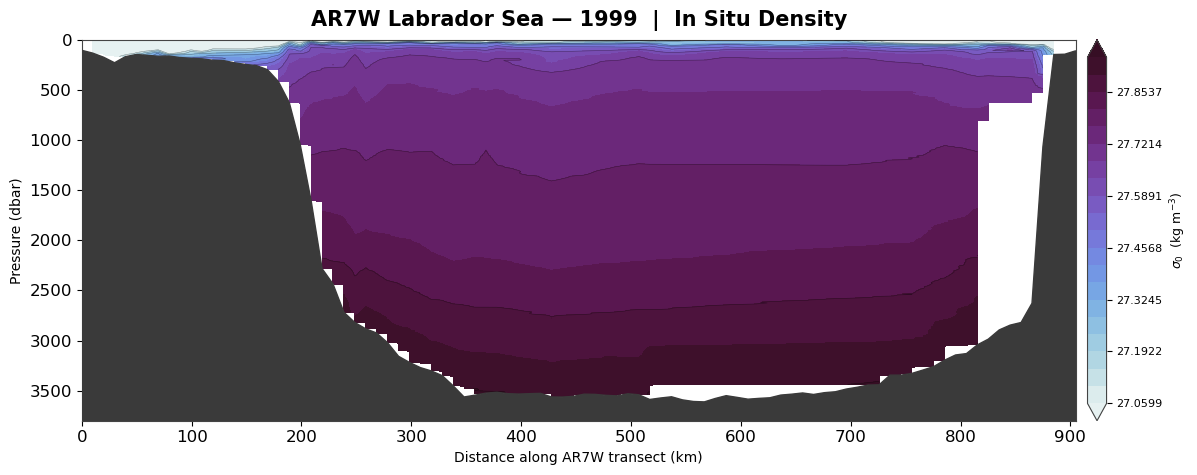

interactive(children=(Dropdown(description='Year:', index=9, layout=Layout(width='200px'), options=(1990, 1991…

In [29]:
# ── Widget ────────────────────────────────────────────────────────────────────
year_widget = widgets.Dropdown(
    options=years,
    value=1999,
    description="Year:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="200px"),
)

widgets.interactive(plot_transect, year=year_widget)

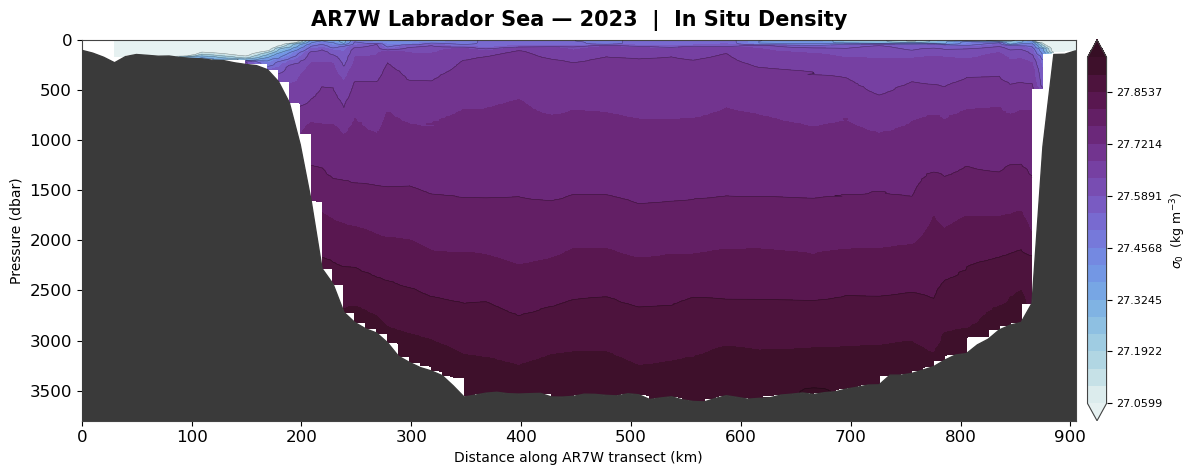

interactive(children=(Dropdown(description='Year:', index=31, layout=Layout(width='200px'), options=(1990, 199…

In [30]:
# ── Widget ────────────────────────────────────────────────────────────────────
year_widget = widgets.Dropdown(
    options=years,
    value=2023,
    description="Year:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="200px"),
)

widgets.interactive(plot_transect, year=year_widget)

## Look at map of profiles for 1999 and 2023

In [38]:
# Open bathymetry
# bathy = xr.open_dataset('/Users/mzahn/data/GEBCO/GEBCO_2023.nc')
bathy = xr.open_dataset("~/efs-mount-point/mzahn/data/bathy/gebco_2021_sub_ice_n90.0_s30.0_w-120.0_e30.0.nc")
bathy_greenland = bathy.elevation.sel(lon=slice(-65, -35),lat=slice(50, 70)).isel(lon=slice(None, None, 10),lat=slice(None, None, 10))

In [42]:
def plot_ar7w_year(year: int):
    """
    Plot AR7W observations (scatter) and density transect (line) for a given year.

    Parameters
    ----------
    year : int
        The year to plot (e.g. 1999, 2005, 2015)
    """
    # --- Load datasets ---
    ar7w_ds = xr.open_dataset("~/efs-mount-point/mzahn/data/ar7w/igor_ar7w.nc")
    density_ds = xr.open_dataset("~/efs-mount-point/mzahn/data/ar7w/ar7w_density_transects.nc")

    # --- Filter to selected year ---
    ar7w_year = ar7w_ds.sel(time=ar7w_ds.time.dt.year == year)
    a
    = density_ds.sel(year=year)

    if ar7w_year.sizes['time'] == 0:
        print(f"No AR7W observations found for year {year}.")
        return

    # --- Extract months for colormap ---
    months = ar7w_year.time.dt.month.values

    # --- Colormap setup (1–12 months) ---
    cmap = cm.get_cmap('turbo', 12)
    norm = mcolors.BoundaryNorm(boundaries=range(1, 14), ncolors=12)

    # --- Plot ---
    plt.rcParams['font.size'] = 14
    fig = plt.figure(figsize=(8, 7))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
    ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())

    # Scatter plot — ar7w_ds (colored by month)
    sc = ax.scatter(
        ar7w_year.longitude,
        ar7w_year.latitude,
        c='tab:cyan',
        cmap=cmap,
        norm=norm,
        marker='v',
        s=15,
        transform=ccrs.PlateCarree(),
        zorder=5,
        label=f'AR7W obs ({year})'
    )

    # Line plot — density transect
    if 'time' in density_year.dims and density_year.sizes['time'] > 1:
        for t in range(density_year.sizes['time']):
            ax.plot(
                density_year.longitude.isel(time=t),
                density_year.latitude.isel(time=t),
                color='magenta',
                linewidth=1.5,
                transform=ccrs.PlateCarree(),
                label='Density transect' if t == 0 else None
            )
    else:
        ax.plot(
            density_year.longitude,
            density_year.latitude,
            color='magenta',
            linewidth=1.5,
            transform=ccrs.PlateCarree(),
            label='Density transect'
        )

    # --- Coastlines and land ---
    ax.coastlines()
    ax.add_feature(cfeature.LAND, color='lightgray')

    # --- Bathymetry contours ---
    bathy_levels = [-3000, -1000]
    ax.contour(
        bathy_greenland.lon, bathy_greenland.lat, bathy_greenland,
        levels=bathy_levels, colors='black', linewidths=0.8,
        linestyles='solid', transform=ccrs.PlateCarree()
    )

    # --- Title with date range ---
    start_str = np.datetime_as_string(ar7w_year.time.min().values, unit='D')
    end_str = np.datetime_as_string(ar7w_year.time.max().values, unit='D')
    plt.title(f"AR7W Line & Density Transect\n({start_str} to {end_str})")

    ax.legend(loc='lower left', fontsize=10)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_24601/3642394288.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('turbo', 12)
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  result = super().scatter(*args, **kwargs)


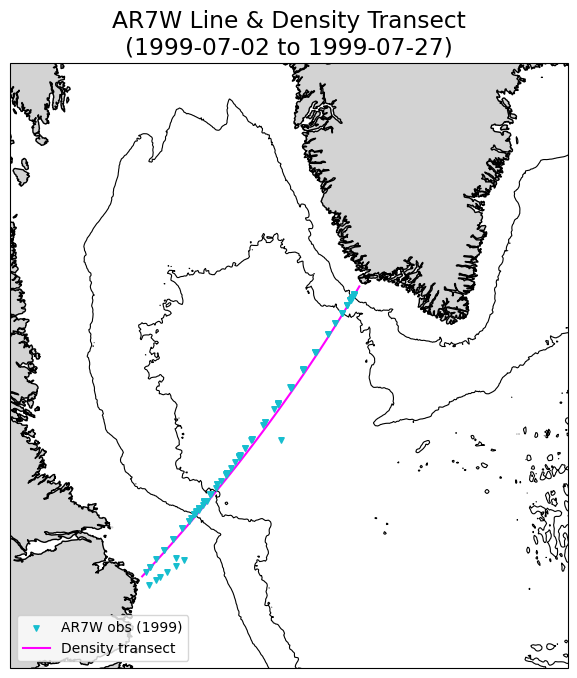

/tmp/ipykernel_24601/3642394288.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('turbo', 12)
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  result = super().scatter(*args, **kwargs)


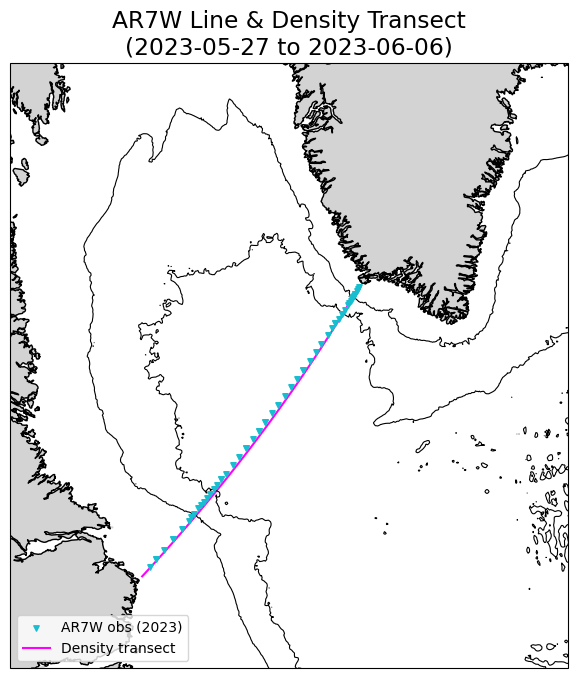

In [43]:
plot_ar7w_year(1999)
plot_ar7w_year(2023)

In [45]:
print(density_ds)

<xarray.Dataset> Size: 134MB
Dimensions:                   (year: 34, distance_km: 92, pressure: 763)
Coordinates:
  * year                      (year) int64 272B 1990 1991 1992 ... 2024 2025
  * distance_km               (distance_km) float64 736B 0.0 9.943 ... 904.8
  * pressure                  (pressure) uint16 2kB 5 10 15 ... 3805 3815 3820
    latitude                  (distance_km) float64 736B 53.56 53.64 ... 60.62
    longitude                 (distance_km) float64 736B -55.66 ... -48.17
Data variables:
    density                   (year, distance_km, pressure) float64 19MB ...
    sigma0                    (year, distance_km, pressure) float64 19MB ...
    sigma1                    (year, distance_km, pressure) float64 19MB ...
    temperature               (year, distance_km, pressure) float64 19MB ...
    salinity                  (year, distance_km, pressure) float64 19MB ...
    absolute_salinity         (year, distance_km, pressure) float64 19MB ...
    conservative_tem

## Plot dynamic height

In [4]:
# ── Load data ─────────────────────────────────────────────────────────────────
ds = xr.open_dataset("~/efs-mount-point/mzahn/data/ar7w/ar7w_dynamic_height.nc")
dh = ds.dynamic_height   # dims: (year, distance_km)

In [6]:
from matplotlib.ticker import MultipleLocator

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

import cmocean   # pip install cmocean  — optional but great for oceanographic colormaps

/tmp/ipykernel_49952/1767486569.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_lines = cm.get_cmap("plasma", len(years))          # one color per year


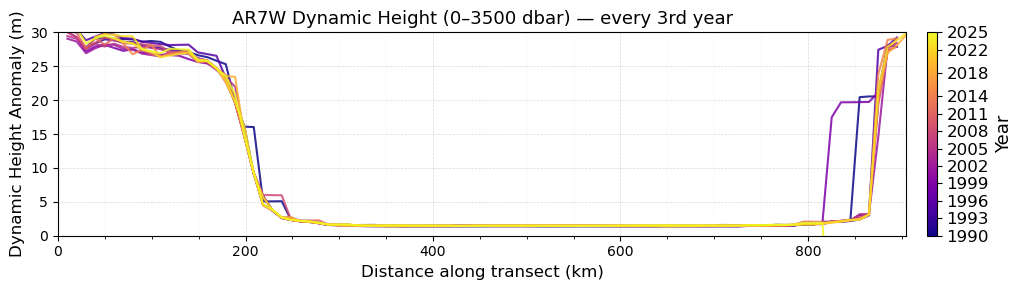

In [14]:
years     = dh.year.values
distances = dh.distance_km.values


# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Spaghetti: one line every 3 years, colored by time
# ══════════════════════════════════════════════════════════════════════════════

# Pick every 3rd year
years_to_plot = years[::3]
n_lines       = len(years_to_plot)

# Colormap spanning the full year range for consistent color meaning
cmap_lines = cm.get_cmap("plasma", len(years))          # one color per year
norm_lines = mcolors.Normalize(vmin=years.min(), vmax=years.max())

fig1, ax1 = plt.subplots(figsize=(11, 3))

for yr in years_to_plot:
    profile = dh.sel(year=yr).values
    color   = cmap_lines(norm_lines(yr))
    ax1.plot(distances, profile, color=color, linewidth=1.5, alpha=0.85, label=str(yr))

# Colorbar to show the year axis
sm = cm.ScalarMappable(cmap="plasma", norm=norm_lines)
sm.set_array([])
cbar1 = fig1.colorbar(sm, ax=ax1, pad=0.02)
cbar1.set_label("Year", fontsize=13)
cbar1.set_ticks(years_to_plot)
cbar1.ax.tick_params(labelsize=12)

ax1.set_xlabel("Distance along transect (km)", fontsize=12)
ax1.set_ylabel("Dynamic Height Anomaly (m)", fontsize=12)
ax1.set_title("AR7W Dynamic Height (0–3500 dbar) — every 3rd year", fontsize=13)
ax1.set_xlim(distances[0], distances[-1])
ax1.xaxis.set_minor_locator(MultipleLocator(50))
ax1.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax1.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.3)

ax1.set_ylim(0,30)

plt.tight_layout()
plt.show()

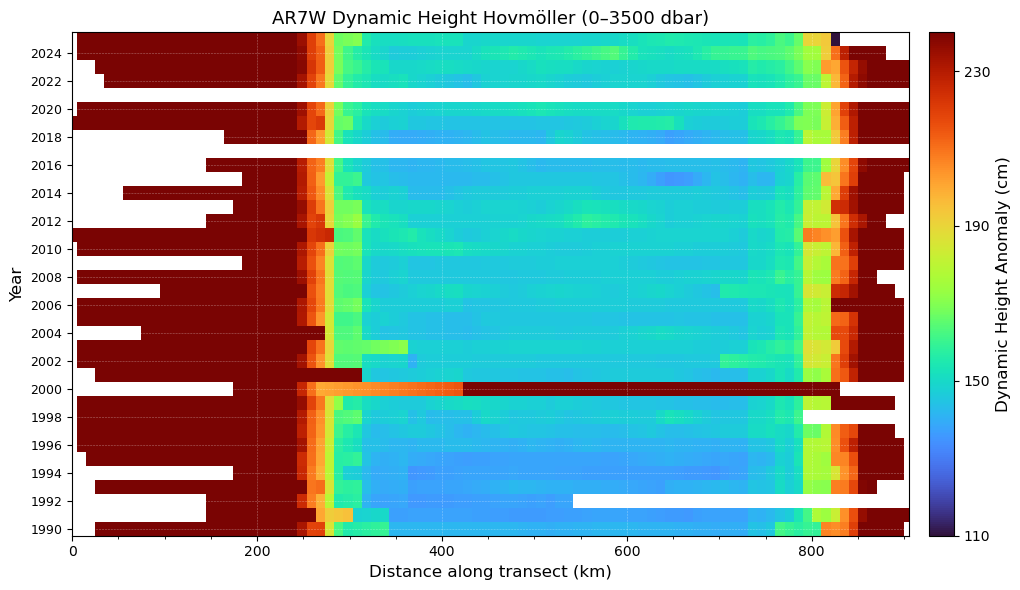

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Hovmöller: distance_km (x) vs year (y), color = dynamic height
# ══════════════════════════════════════════════════════════════════════════════

# Convert to cm
data_2d_cm = dh.values * 100.0   # m -> cm

# Insert NaN rows for years with no data (2017, 2020) so they appear as blank
# bands in the plot rather than interpolating across missing years
missing_years = [2017, 2021]
all_years     = np.arange(years.min(), years.max() + 1)   # continuous year axis
n_all         = len(all_years)
data_full     = np.full((n_all, len(distances)), np.nan)

for i, yr in enumerate(all_years):
    if yr in years and yr not in missing_years:
        data_full[i, :] = data_2d_cm[np.where(years == yr)[0][0], :]
    # rows for missing_years stay as NaN — will render as blank/white cells

# Use cmocean 'haline' or fall back to viridis — sequential suits 0–10 cm range
try:
    cmap_hov = cmocean.cm.haline
except NameError:
    cmap_hov = "turbo"

vmin, vmax = 110, 240   # fixed colorbar range in cm

fig2, ax2 = plt.subplots(figsize=(11, 6))

pcm = ax2.pcolormesh(
    distances,
    all_years,
    data_full,
    cmap=cmap_hov,
    vmin=vmin,
    vmax=vmax,
    shading="auto"
)

cbar2 = fig2.colorbar(pcm, ax=ax2, pad=0.02)
cbar2.set_label("Dynamic Height Anomaly (cm)", fontsize=12)
cbar2.set_ticks(np.arange(110, 241, 40))

ax2.set_xlabel("Distance along transect (km)", fontsize=12)
ax2.set_ylabel("Year", fontsize=12)
ax2.set_title("AR7W Dynamic Height Hovmöller (0–3500 dbar)", fontsize=13)
ax2.set_xlim(distances[0], distances[-1])
ax2.set_yticks(all_years[::2])      # label every other year to avoid crowding
ax2.tick_params(axis="y", labelsize=9)
ax2.xaxis.set_minor_locator(MultipleLocator(50))
ax2.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.4, color="white")

plt.tight_layout()
plt.show()

In [35]:
import matplotlib.ticker as ticker

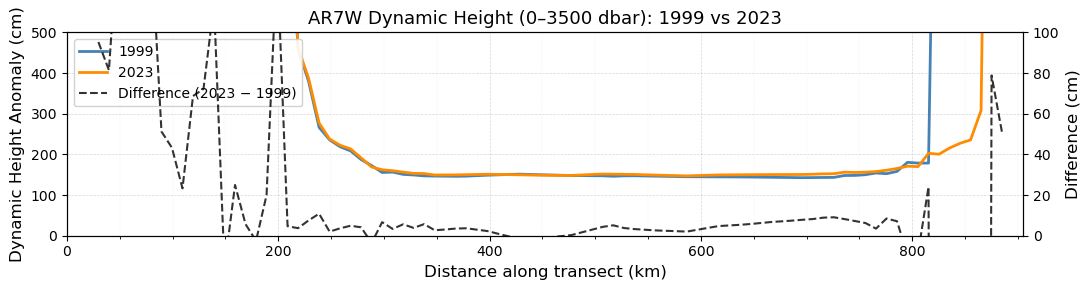

In [44]:
# Extract the two years and convert to cm
dh_1990 = dh.sel(year=1990).values * 100.0
dh_2023 = dh.sel(year=2023).values * 100.0
diff     = dh_2023 - dh_1999   # positive = higher in 2023

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 3))

# Primary axis — dynamic height for each year
l1, = ax1.plot(distances, dh_1999, color="steelblue",  linewidth=2,   label="1999")
l2, = ax1.plot(distances, dh_2023, color="darkorange", linewidth=2,   label="2023")

ax1.set_xlabel("Distance along transect (km)", fontsize=12)
ax1.set_ylabel("Dynamic Height Anomaly (cm)", fontsize=12)
ax1.set_xlim(distances[0], distances[-1])
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax1.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax1.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.3)

# Secondary axis — 2023 minus 1999 difference
ax2 = ax1.twinx()
l3, = ax2.plot(distances, diff, color="k", linewidth=1.5,
               linestyle="--", alpha=0.8, label="Difference (2023 − 1999)")
ax2.axhline(0, color="k", linewidth=0.7, linestyle=":", alpha=0.5)
ax2.set_ylabel("Difference (cm)", fontsize=12, color="k")
ax2.tick_params(axis="y", labelcolor="k")

# limits
ax1.set_ylim(0,500)
ax2.set_ylim(0,100)

# ── Combined legend ───────────────────────────────────────────────────────────
lines  = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=10, framealpha=0.9)

plt.title("AR7W Dynamic Height (0–3500 dbar): 1999 vs 2023", fontsize=13)
plt.tight_layout()
plt.show()

In [67]:
# ── Load data ─────────────────────────────────────────────────────────────────
ds = xr.open_dataset("~/efs-mount-point/mzahn/data/ar7w/ar7w_dynamic_height.nc")
dh = ds.dynamic_height   # dims: (year, distance_km)

distances = dh.distance_km.values


def plot_dyn_height_comparison(year_a, year_b, ylim_primary=(120, 180), ylim_diff=(0, 30)):
    """
    Plot dynamic height for two years on a shared transect axis,
    with a secondary axis showing their difference (year_b - year_a).

    Parameters
    ----------
    year_a       : int   - first year (plotted in blue, subtracted in diff)
    year_b       : int   - second year (plotted in orange, defines diff sign)
    ylim_primary : tuple - (ymin, ymax) for the dynamic height axis in cm
    ylim_diff    : tuple - (ymin, ymax) for the difference axis in cm
    """
    dh_a = dh.sel(year=year_a).values * 100.0
    dh_b = dh.sel(year=year_b).values * 100.0
    diff = dh_b - dh_a   # positive = higher in year_b

    fig, ax1 = plt.subplots(figsize=(11, 3))

    # Primary axis — dynamic height for each year
    l1, = ax1.plot(distances, dh_a, color="steelblue",  linewidth=2, label=str(year_a))
    l2, = ax1.plot(distances, dh_b, color="darkorange", linewidth=2, label=str(year_b))

    ax1.set_xlabel("Distance along transect (km)", fontsize=12)
    ax1.set_ylabel("Dynamic Height (cm)", fontsize=12)
    ax1.set_xlim(distances[0], distances[-1])
    ax1.set_ylim(*ylim_primary)
    ax1.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax1.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
    ax1.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.3)

    # Secondary axis — year_b minus year_a
    ax2 = ax1.twinx()
    l3, = ax2.plot(distances, diff, color="k", linewidth=1.5,
                   linestyle="--", alpha=0.8, label=f"Difference ({year_b} − {year_a})")
    ax2.axhline(0, color="k", linewidth=0.7, linestyle=":", alpha=0.5)
    ax2.set_ylabel("Difference (cm)", fontsize=12, color="k")
    ax2.tick_params(axis="y", labelcolor="k")
    ax2.set_ylim(*ylim_diff)

    # Combined legend
    lines  = [l1, l2, l3]
    labels = [l.get_label() for l in lines]
    legend = ax1.legend(lines, labels, loc="upper center", fontsize=10, framealpha=1,facecolor='white')
    legend.set_zorder(10)

    plt.title(f"AR7W Dynamic Height (0–3500 dbar): {year_a} vs {year_b}", fontsize=13)
    plt.tight_layout()
    plt.show()

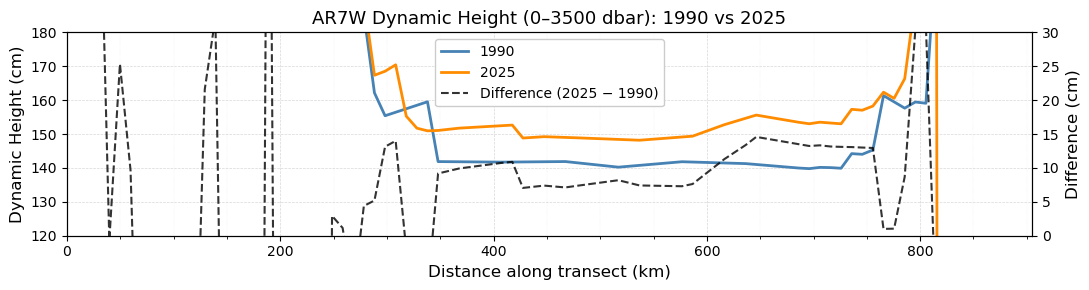

In [69]:
# ── Usage ─────────────────────────────────────────────────────────────────────
plot_dyn_height_comparison(1990, 2025)

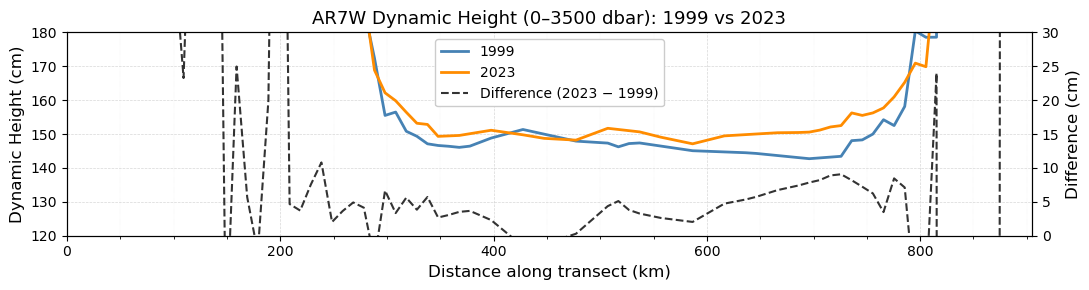

In [68]:
# ── Usage ─────────────────────────────────────────────────────────────────────
plot_dyn_height_comparison(1999, 2023)